<h1><font color="blue">일차원 데이터 Series</font></h1>

<h2><font color="red">Series의 생성과 속성 다루기</font></h2>

In [2]:
# 판다스 가져오기
import pandas as pd

In [3]:
myrange = range(5, 8)
myseries01 = pd.Series(myrange)
myseries01

0    5
1    6
2    7
dtype: int64

In [7]:
mylist01 = [10, 60, 50, 30]
myseries01 = pd.Series(mylist01, index = ["프랑스", "독일", "중국", "미국"])
myseries01

프랑스    10
독일     60
중국     50
미국     30
dtype: int64

In [8]:
sdata = {"일본" : 3000, "영국" : 2000}
myseries01 = pd.Series(sdata)
myseries01

일본    3000
영국    2000
dtype: int64

In [10]:
myseries01.index.name = "국가"

In [12]:
myseries01.name = "국가별 신용도"

In [13]:
myseries01

국가
일본    3000
영국    2000
Name: 국가별 신용도, dtype: int64

In [14]:
print("색인 이름 : " + str(myseries01.index.name))
print("시리즈 이름 : " + str(myseries01.name))

색인 이름 : 국가
시리즈 이름 : 국가별 신용도


In [ ]:
"시리즈의 값 확인 : " + str(myseries01.values)

In [ ]:
"시리즈의 값 확인 : [3000 2000]" 

In [16]:
for idx in myseries01.index:
    print("색인 : " + idx + ", 값 : " + str(myseries01[idx]))

색인 : 일본, 값 : 3000
색인 : 영국, 값 : 2000


In [20]:
myindex02 = ["프랑스", "독일", "중국", "미국", "일본", "영국", "호주"]
mylist02 = [50, 30, 20, 60, 40, 80, 70]
myseries02 = pd.Series(data = mylist02, index = myindex02)
myseries02.to_frame()

,0
프랑스,50
독일,30
중국,20
미국,60
일본,40
영국,80
호주,70


In [21]:
myseries02["미국"]

60

In [22]:
myseries02[["미국"]]

미국    60
dtype: int64

In [23]:
myseries02["미국":"영국"]

미국    60
일본    40
영국    80
dtype: int64

In [25]:
myseries02[["호주", "미국"]]

호주    70
미국    60
dtype: int64

In [27]:
myseries02.iloc[2]

20

In [28]:
myseries02[0:7:3]

프랑스    50
미국     60
호주     70
dtype: int64

In [29]:
myseries02[3:5]

미국    60
일본    40
dtype: int64

In [40]:
myseries02.iloc[2] = 22
myseries02[2:5] = 55
myseries02[["프랑스", "미국"]] = 33
myseries02

프랑스    33
독일     30
중국     55
미국     33
일본     55
영국     80
호주     77
dtype: int64

In [41]:
myseries02[0::2] = 77

In [43]:
result = myseries02[myseries02 < 50]
result

독일    30
미국    33
dtype: int64

In [42]:
myseries02.to_frame()

,0
프랑스,77
독일,30
중국,77
미국,33
일본,77
영국,80
호주,77


In [45]:
myindex31 = ['일본', '영국', '호주', '독일']
mylist31 = [30, 40, 50, 60]

myindex32 = ['일본', '영국', '호주', '프랑스']
mylist32 = [20, 40, 60, 70]

myseries31 = pd.Series(data=mylist31, index=myindex31 )
myseries32 = pd.Series(data=mylist32, index=myindex32 )

In [46]:
myseries31.to_frame()

,0
일본,30
영국,40
호주,50
독일,60


In [47]:
myseries32.to_frame()

,0
일본,20
영국,40
호주,60
프랑스,70


In [48]:
myseries31 + 10

일본    40
영국    50
호주    60
독일    70
dtype: int64

In [49]:
myseries31.add(10) # sub, mul, div/floordiv

일본    40
영국    50
호주    60
독일    70
dtype: int64

In [51]:
myseries31.gt(50) # myseries31 > 50

일본    False
영국    False
호주    False
독일     True
dtype: bool

In [52]:
myseries31 + myseries32

독일       NaN
영국      80.0
일본      50.0
프랑스      NaN
호주     110.0
dtype: float64

In [53]:
myseries31.add(myseries32, fill_value = 0) # fill_value = 0 : 서로의 없는 값은 0으로 설정함

독일      60.0
영국      80.0
일본      50.0
프랑스     70.0
호주     110.0
dtype: float64

In [54]:
mylist04 = ['미국', '영국', '영국','중국', '영국', '영국', '일본', '일본', '미국', '미국']
myseries04 = pd.Series(mylist04)
print('시리즈 정보 확인')
print(myseries04)

시리즈 정보 확인
0    미국
1    영국
2    영국
3    중국
4    영국
5    영국
6    일본
7    일본
8    미국
9    미국
dtype: object


In [55]:
myunique04 = myseries04.unique() # abstract 중복되어도 한개만 나오게 하기
myunique04

array(['미국', '영국', '중국', '일본'], dtype=object)

In [58]:
# 값을 기반으로 중복되는 것을 카운트(빈도숫자) (정렬 기본값 : 숫자크기로 정렬)
# 매개변수에 normalize=True를 넣으면 숫자말고 비율로 나옴 (그래프에 넣을 숫자로 이용함)
myseries04.value_counts(normalize=True)

영국    0.4
미국    0.3
일본    0.2
중국    0.1
Name: proportion, dtype: float64

In [59]:
# is -> boolean 타입 / in -> ~ 안에
# isin() -> 값이 ~면 / 복수의 값을 충족하는 매개변수를 넣으려면 []를 사용
mask04 = myseries04.isin(["중국", "미국"])
myseries04[mask04]

0    미국
3    중국
8    미국
9    미국
dtype: object

In [62]:
myindex05 = ['프랑스', '독일', '중국', '미국', '일본', '영국', '호주']
mylist05 = [50, 30, 20, 60, 40, 80, 70]
myseries05 = pd.Series(data=mylist05, index=myindex05)
myseries05.to_frame()

,0
프랑스,50
독일,30
중국,20
미국,60
일본,40
영국,80
호주,70


In [66]:
import matplotlib.pyplot as plt

plt.rc("font", family="Malgun Gothic")

Text(0.5, 1.0, '국가별 신용도 꺽은 선')

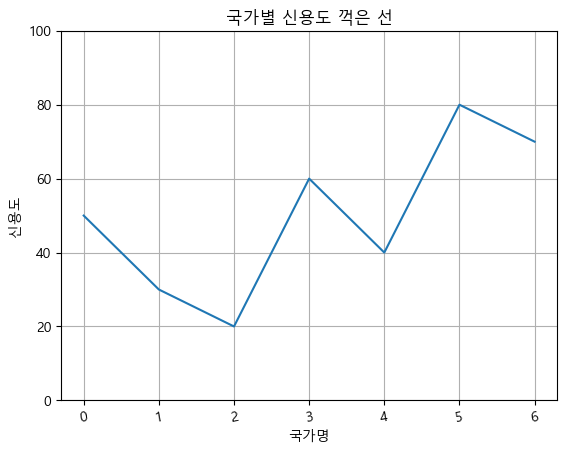

In [71]:
myseries05.plot(kind="line", grid=True, ylim=[0, 100], rot=10, use_index=False)
plt.xlabel("국가명")
plt.ylabel("신용도")
plt.title("국가별 신용도 꺽은 선")

Text(0.5, 1.0, '국가별 신용도 꺽은 선')

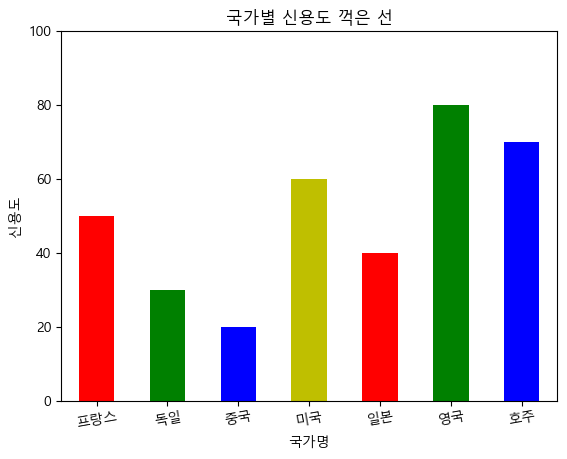

In [75]:
myseries05.plot(kind="bar", grid=False, ylim=[0, 100], rot=10, use_index=True, color=["r", "g", "b", "y"])
plt.xlabel("국가명")
plt.ylabel("신용도")
plt.title("국가별 신용도 꺽은 선")